In [112]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import plotly.graph_objects as go

import os
# from pyfmreaderpsnex.ps_nex.loadMaps import checkMapFileNULL, remove_nan_and_get_indices, load_map_file_csv, compute_time_difference
# from pyfmreaderpsnex.ps_nex.parseTDMS import get_channel_names, parse_tdms, grab_tdms
# from pyfmreaderpsnex.plotting import smooth_derivative
# import plotly.io as pio
# import seaborn as sns
# import sys

from pyfmreader import loadfile
from pyfmreader.ps_nex.parseTDMS import grab_tdms
from pyfmrheo.utils.force_curves import correct_tilt
from scipy.stats import linregress

pi = math.pi
 

### Functions

In [113]:
from scipy.signal import savgol_filter

# scan from left to right, corrected deflection, and check when value becomes positive
def find_first_positive(arr):
    """
    Returns an array of first positives in a NumPy array.
    Returns None if no positive value is found.
    """
    arr = np.asarray(arr)
    positives = np.where(arr > 0)[0]
    return positives if positives.size > 0 else None

def savitzky_golay_smooth(y, window_length=11, polyorder=3):
    """
    Applies Savitzky-Golay smoothing to a 1D array.

    Parameters:
    - y: array-like, the signal to smooth
    - window_length: int, length of the filter window (must be odd and >= polyorder+2)
    - polyorder: int, order of the polynomial used to fit the samples

    Returns:
    - smoothed_y: numpy array, the smoothed signal
    # """
    y = np.asarray(y)
    # Ensure window_length is odd and less than or equal to the size of y
    if window_length % 2 == 0:
        window_length += 1
    if window_length > len(y):
        window_length = len(y) if len(y) % 2 == 1 else len(y) - 1
    return savgol_filter(y, window_length=window_length, polyorder=polyorder)



### Read file and parse necessary data

In [114]:
file_path = '/Users/evillz/Data/article/2025_07_01_THP1_phd/cell2/03/fcurve_thp1_cell1_ret_03ums__2025.07.01_17.31.15.19.tdms'
directory = '/Users/evillz/Data/article/2025_07_01_THP1_phd/cell2/600/'
# AC10 super fast retract
directory = '/Users/evillz/Data/article/20205_07_22_Thp1_AC10/canti1/cell1/600'

show_plots = True

first_file, all_files = grab_tdms(directory)

print(f'number of tdms files found: {len(all_files)}')

number of tdms files found: 105


In [115]:
# Load File
filename = all_files[2] #or 31, 29
file = loadfile(filename)
filemetadata = file.filemetadata
print(filemetadata['file_type'])
print(f'analyzing file: {filename}')

segment_0_ramp_speed_um/s: 20 um/s
segment_1_ramp_speed_um/s: 0 um/s
segment_2_ramp_speed_um/s: 600 um/s
PSNEX.tdms
analyzing file: /Users/evillz/Data/article/20205_07_22_Thp1_AC10/canti1/cell1/600/fcurve_THP1_AC10_FastVelocities__2025.07.22_15.30.53.23.tdms


In [116]:
# Filemetadata
file_deflection_sensitivity = filemetadata['defl_sens_nmbyV'] #nm/V
K = filemetadata['spring_const_Nbym'] #N/m
height_channel_key = filemetadata['height_channel_key']
deflection_channel_key = filemetadata['deflection_chanel_key']

defl_sens = file_deflection_sensitivity / 1e9 #m/V

print(f"Height channel: {height_channel_key}")
print(f"Deflection Sens.: {defl_sens} m/V")
print(f"spring_const_Nbym: {K} N/m")

Height channel: Zpiezo_stage_sensor_(V)
Deflection Sens.: 2.67e-08 m/V
spring_const_Nbym: 0.1 N/m


In [117]:
# Select curve by index
curve_idx = 0
try : 
    force_curve = file.getcurve(curve_idx)
except IndexError:
    print(f"Curve index {curve_idx} does not exist in the file.")
    force_curve = None  

# Preprocess curve to get the segments
try:
    denoise_method = 'savitzky_golay'  # or 'median', 'mean', etc.
    force_curve.preprocess_force_curve(defl_sens, height_channel_key)
    # force_curve.denoise_segments(denoise_method)
except Exception as e:
    print(f"Error occurred during preprocessing: {e}")


decimation: [10  1  1]
z_sensor_delay: 0, bool_correct_overshoot: False 
points removed : 0
Deflection Length: 270657, Height: 270657
0 126245
segment relative position: 126245, segment duration: 2.5249075
App
removed overshoot
start_indices: [     0 126245 232808]
end_indices: [126245 232808 270657]
NumPnts: [126245 106563  37847]
---------------------
126245 232808
segment relative position: 106563, segment duration: 0.21312689999999998
Con
start_indices: [     0 126245 232808]
end_indices: [126245 232808 270657]
NumPnts: [126245 106563  37847]
---------------------
232808 270657
segment relative position: 37849, segment duration: 0.075695075
Ret
start_indices: [     0 126245 232808]
end_indices: [126245 232808 270657]
NumPnts: [126245 106563  37847]
---------------------


In [118]:
# Get segments and indentation
segs = force_curve.get_segments()
# these metadata is only available after getting segments
final_nb_points = filemetadata['final_nb_points']
relative_dt = filemetadata['relative_sr']

# get details of retract segments
for segid, segment in segs:
    if segment.segment_type in ('Retract', 'Ret'):
        # print(f"Segment ID: {segid}, Type: {segment.segment_type}")
        relative_dt_ret = relative_dt[segid]
        vel_ret_um_s = segment.velocity * 1e-03  # Convert nm/s to um/s


37849, 37849, 37849
Total length of the force curve without contact: 57531
164094 164094


/var/folders/kc/jykhdgwx4p3696y51hzh6j3r0000gn/T/ipykernel_10525/3898675114.py:23: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



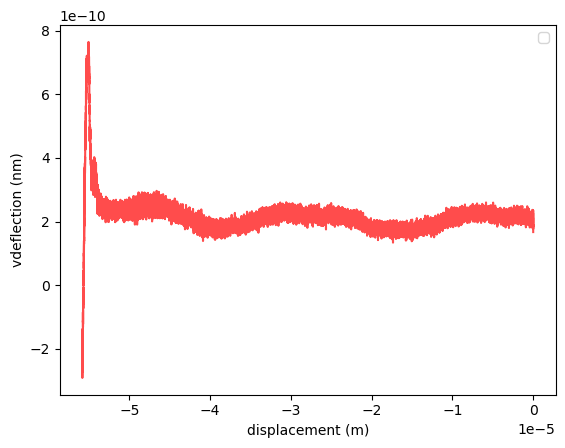

In [119]:
# Get zheight and vdeflection, for now only get retract
zmin_app = 0
for segid, segment in force_curve.get_segments():
    if segment.segment_type in ('Approach', 'App'):
        zmin_app = segment.zheight.min()
        app_piezo = -segment.zheight
        app_deflection = -segment.vdeflection * K  # Convert to N
        # if show_plots:
        #     plt.plot(segment.zheight-zmin_app, segment.vdeflection, 'g-', linewidth=1.5, label=f'{segment.segment_type}', alpha=0.7)
    elif segment.segment_type in ('Retract', 'Ret'):
        ret_piezo = -segment.zheight
        ret_deflection = -segment.vdeflection * K  # Convert to N
        time_ret = np.arange(len(ret_piezo)) * relative_dt_ret  # Assuming relative_SR_ret is in Hz, convert to seconds
        print (f"{len(ret_piezo)}, {len(ret_deflection)}, {len(time_ret )}")
        # if show_plots:
        #     plt.plot(segment.zheight - zmin_app, segment.vdeflection, 'r-', linewidth=1.5, label=f'{segment.segment_type}', alpha=0.7)
    elif segment.segment_type in ('Contact', 'Con', 'Pause'):
        con_piezo = -segment.zheight
        con_deflection = -segment.vdeflection * K  # Convert to N
        # if show_plots:
        #     plt.plot(segment.zheight-zmin_app, segment.vdeflection, 'b-', linewidth=1.5, label=f'{segment.segment_type}', alpha=0.7)
if show_plots:
    plt.legend()
    plt.xlabel('displacement (m)')
    plt.ylabel('vdeflection (nm)')

# depening if there is a value , get length of total force curve: app+ con + ret
if 'con_piezo' in locals():
    total_length = len(app_piezo) - len(con_piezo) + len(ret_piezo)
print(f"Total length of the force curve without contact: {total_length}")


deflection_N = np.concatenate((app_deflection, ret_deflection))
zheight = np.concatenate((app_piezo, ret_piezo)) 

print (len(zheight), len(deflection_N))

plt.plot(ret_piezo, ret_deflection, 'r-', linewidth=1.5, label='Retract', alpha=0.7)
plt.show()

### Calculate retract Velocity
retract velocity calculated from linnear regression fit, the slope would be the calcualted average velocity

Calculated average velocity: 781.49 um/s
metadata_ret_velocity: 600.00 um/s
% Error: 30.25%


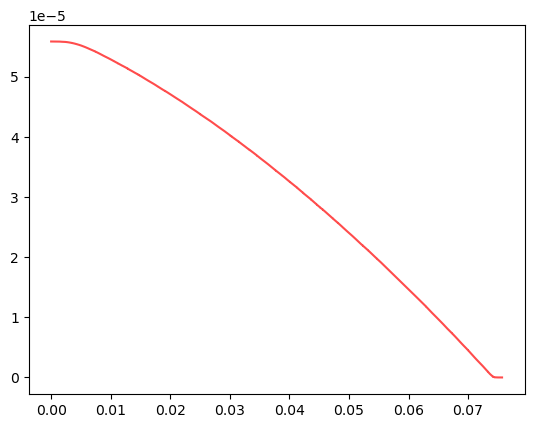

In [120]:
from scipy.stats import linregress

def calculate_velocity(displacement_um, rel_time):
    """
    Calculate the average velocity from displacement_um and time arrays using linear regression.

    Parameters:
        displacement_um (np.ndarray): Displacement values (in micrometers).
        rel_time (np.ndarray): Time values (in seconds).

    Returns:
        float: Average velocity (slope) in µm/s.
    """
    displacement_um = -displacement_um * 1e6  # Convert to micrometers (for compatibility with previous code)
    # deriv_displacement = np.gradient(displacement_um, rel_time)
    slope, intercept, _, _, _= linregress(rel_time, displacement_um)
    return slope
calculated_velocity = calculate_velocity(-ret_piezo, time_ret) 
# print(f'{len(ret_piezo)}, {len(time_ret)}')
print (f"Calculated average velocity: {calculated_velocity:.2f} um/s" )
print(f'metadata_ret_velocity: {vel_ret_um_s:.2f} um/s')

# calculate percent difference from the calculated velocity and the metadata velocity

percent_difference = ((calculated_velocity - vel_ret_um_s) / vel_ret_um_s) *100
print(f"% Error: {percent_difference :.2f}%") 

plt.plot(time_ret, -ret_piezo, 'r-', linewidth=1.5, label='Retract', alpha=0.7)

### Tilt correction
- taken from pyfmrheo

In [121]:
def update_tilt_range(zheight, max, min, offset_type='percentage'):
    if offset_type == 'percentage':
        deltaz = zheight.max() - zheight.min()
        maxperc = max / 1e2
        minperc = min / 1e2
        maxoffset = zheight.min() + deltaz * maxperc
        minoffset = zheight.min() + deltaz * minperc
    elif offset_type == 'absolute':
        maxoffset = max / 1e9
        minoffset = min / 1e9
    return maxoffset, minoffset

max_offset = 100  # %
min_offset = 30  # %

max_offset, min_offset = update_tilt_range(ret_piezo, max_offset, min_offset, offset_type='percentage')
tilt_ret_deflection_N = correct_tilt(ret_piezo, ret_deflection, max_offset, min_offset)


# if show_plots:
    # plt.plot(ret_piezo, tilt_ret_deflection_N, 'k--', color='blue', linewidth=1.5, label='Tilt Corrected Force curve')
    # plt.legend()

### Filter out unecssary noise

For 1000 velocity: 0.1-15, ranges = [(0.2,0.5),(2, 6)]
For 600 velocity: 

3784
xmax: 53.2411017519073 µm, N: 34065, T: 0.0015629726911668418 µm/sample
Smallest step: 0.0015629726911612352 µm


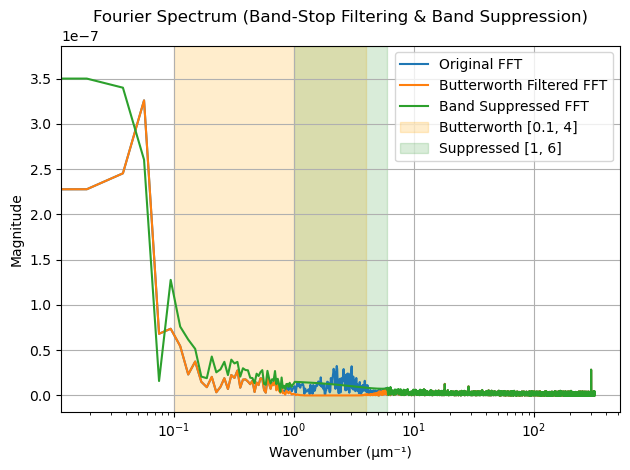

In [136]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from scipy.signal import detrend

def suppress_fourier_band(signal, sampling_rate, velocity, w_range, remove=0, interp=True):
    signal_trimmed = signal[remove:]
    N = len(signal_trimmed)
    T = velocity / sampling_rate  # µm/sample

    yf = fft(signal_trimmed)
    xf = fftfreq(N, T)

    xf_half = xf[:N//2]
    yf_half = yf[:N//2]

    # Get mask only for positive frequencies
    mask = (xf_half >= w_range[0]) & (xf_half <= w_range[1])
    xf_masked = xf_half[mask]
    yf_masked = yf_half[mask]

    if len(xf_masked) == 0:
        return signal.copy()  # Skip if no points in range
    
    yf_interp = yf.copy()
    if interp:
        # Interpolate suppressed region
        interp_vals = np.interp(xf_masked, [xf_masked[0], xf_masked[-1]],
                                [yf_masked[0], yf_masked[-1]])

        # Rebuild full FFT with interpolated suppression
        yf_interp = yf.copy()
        yf_interp[:N//2][mask] = interp_vals
        yf_interp[-(N//2):][::-1][mask] = np.conj(interp_vals)  # maintain Hermitian symmetry
    else:
        # Zero out the frequencies in the specified range
        yf_interp[:N//2][mask] = 0
        yf_interp[-(N//2):][::-1][mask] = 0

    signal_filtered = np.real(ifft(yf_interp))
    full_output = signal.copy()
    full_output[remove:] = signal_filtered
    return full_output

# --- Butterworth Band-Stop Filter ---
def butterworth_bandstop(xf, f_low, f_high, order=5):
    f_center = (f_low + f_high) / 2
    bandwidth = f_high - f_low
    eps = 1e-12
    return 1 / (1 + ((xf * bandwidth) / ((xf**2 - f_center**2) + eps))**(2 * order))


# --- Processing starts ---
remove_start = 10 #percent
remove_index = remove_start * len(ret_piezo) // 100
print (remove_index)
remove = remove_index
ret_piezo_new = ret_piezo[remove:]
def_new = detrend(tilt_ret_deflection_N[remove:])

sampling_rate = 1 / relative_dt_ret  # Hz
N = len(def_new)
T = calculated_velocity / sampling_rate  # µm/sample
x = np.linspace(0.0, N*T, N, endpoint=False)
print(f'xmax: {x.max()} µm, N: {N}, T: {T} µm/sample')
print(f'Smallest step: {np.min(np.diff(x))} µm')

# FFT
yf = fft(def_new)
xf = fftfreq(N, T)


W0 = 0.1
W1 = 4
butter_mask = butterworth_bandstop(xf, W0, W1, order=4)
yf_filtered = yf * butter_mask
filtered_deflection = np.real(ifft(yf_filtered))

filtered_signal = tilt_ret_deflection_N.copy()
filtered_signal[remove:] = filtered_deflection

# --- Apply Multiple Fourier Band Suppressions ---
ranges = [(1, 6)]  # You can add more bands here
fft_filtered_signal = tilt_ret_deflection_N.copy()
for r in ranges:
    fft_filtered_signal = suppress_fourier_band(
        fft_filtered_signal,
        sampling_rate=sampling_rate,
        velocity=calculated_velocity,
        w_range=r,
        remove=remove,
        interp=True,
    )

# --- Plot FFT before/after filtering, including band suppressions ---
plt.figure()
plt.plot(xf[:N//2], np.abs(yf[:N//2]), label='Original FFT')
plt.plot(xf[:N//2], np.abs(yf_filtered[:N//2]), label='Butterworth Filtered FFT')

# FFT after band suppression
yf_band = fft(fft_filtered_signal[remove:])
plt.plot(xf[:N//2], np.abs(yf_band[:N//2]), label='Band Suppressed FFT')

plt.xlabel('Wavenumber (µm⁻¹)')
plt.ylabel('Magnitude')
plt.title('Fourier Spectrum (Band-Stop Filtering & Band Suppression)')
plt.axvspan(W0, W1, color='orange', alpha=0.2, label=f'Butterworth [{W0}, {W1}]')
for r in ranges:
    plt.axvspan(r[0], r[1], color='green', alpha=0.15, label=f'Suppressed [{r[0]}, {r[1]}]')
plt.xscale('log')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [135]:
# plot in plotly
fig = go.Figure()
fig.add_trace(go.Scatter(x=ret_piezo, y=tilt_ret_deflection_N, mode='lines', name='Tilt corrected Retract', line=dict(color='red', width=2)))
fig.add_trace(go.Scatter(x=ret_piezo, y=fft_filtered_signal, mode='lines', name='Filtered Signal', line=dict(color='blue', width=2)))
fig.update_layout(title='Tilt Corrected Force Curve', xaxis_title='Piezo Position (m)', yaxis_title='Deflection (N)', showlegend=True)
fig.show()      

### Find contact point of retract
- take the index at which the negative deflection turns positive

In [124]:
contact_point_offset = 0.0  # m
index_first_positive = find_first_positive(fft_filtered_signal)[0]
print (f"Index of first positive value in corrected deflection: {index_first_positive}")

first_positive_deflection = fft_filtered_signal[index_first_positive]
first_positive_displacement = ret_piezo[index_first_positive]
print(f"First positive deflection: {first_positive_deflection}, at displacement: {first_positive_displacement}")

Index of first positive value in corrected deflection: 1687
First positive deflection: 4.569399680624046e-12, at displacement: -5.559575271606445e-05


In [125]:
ret_corrected_displacement = ret_piezo - first_positive_displacement

In [126]:
# Find the maximum positive value in corrected_deflection_ret
positive_values = fft_filtered_signal[fft_filtered_signal > 0]
if positive_values.size > 0:
    max_positive_value = np.max(positive_values)
    print(f"Max positive value in corrected_deflection_ret: {max_positive_value}")
else:
    print("No positive values found in corrected_deflection_ret.")

Max positive value in corrected_deflection_ret: 5.666701111437836e-10


In [134]:
# plot in plotly
fig = go.Figure()
fig.add_trace(go.Scatter(x=ret_piezo, y=tilt_ret_deflection_N, mode='lines', name='Tilt corrected Retract', line=dict(color='red', width=2)))
fig.add_trace(go.Scatter(x=ret_piezo, y=fft_filtered_signal, mode='lines', name='Filtered Signal', line=dict(color='blue', width=2)))
fig.add_trace(go.Scatter(x=[0], y=[first_positive_deflection], mode='markers', name='Point of Contact', marker=dict(color='green', size=8)))
fig.add_trace(go.Scatter(x=ret_corrected_displacement, y=fft_filtered_signal, mode='lines', name='Corrected Displacement', line=dict(color='purple', width=2))) 
fig.update_layout(title='Tilt Corrected Force Curve', xaxis_title='Piezo Position (m)', yaxis_title='Deflection (N)', showlegend=True)
fig.show()      

### Do savtisky smoothing on deflection

In [128]:
# window length needs to be higher than polyorder!
savitz_defl = savitzky_golay_smooth(fft_filtered_signal, window_length=5,polyorder=1) 

-7.329339974298577e-11


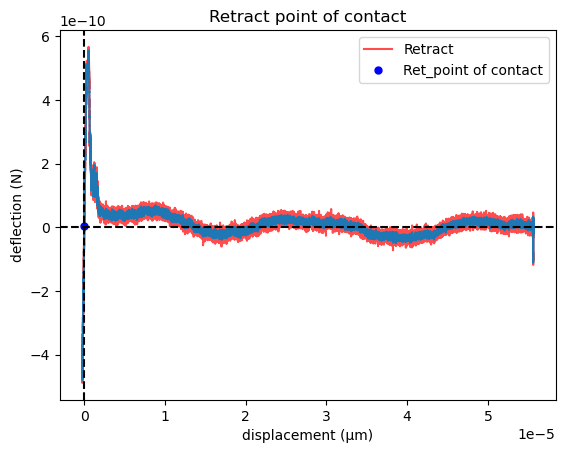

In [129]:
plt.plot(ret_corrected_displacement, fft_filtered_signal, 'r-', linewidth=1.5, label='Retract', alpha=0.7)
plt.plot(ret_corrected_displacement, savitz_defl)
plt.plot(0, first_positive_deflection, 'o', color='blue', markersize=5, label='Ret_point of contact')  #

y_lower_limit = filtered_signal.min()*0.15 # show 10 percent from the lowest value
print(y_lower_limit)
# plt.ylim(y_lower_limit ,max_positive_value*1.1)
plt.axhline(y=0, color='k', linestyle='--')
plt.axvline(x=0, color='k', linestyle='--')
plt.ylabel('deflection (N)')
plt.xlabel('displacement (µm)')
plt.title('Retract point of contact')
plt.legend()

### find plateaus

In [130]:


def find_plateaus(x , y, params=None, dt = 1e-3):
    """
    Identify plateaus in 1D data where the first derivative is close to 0.

    Parameters:
        y (array): 1D signal (e.g., deflection).
        params (dict, optional): Dictionary of parameters to override defaults:
            - 'sav_window_length' (int): Window length for Savitzky-Golay smoothing.
            - 'sav_polyorder' (int): Polynomial order for Savitzky-Golay filter.
            - 'pl_threshold' (float): Max allowed slope (abs(dy/dx)) for plateau detection.
            - 'pl_min_width_um' (int): Minimum length (in points) of a plateau.
            - 'last_num_plateaus' (int): Number of plateaus to keep from the end.
        dt (float, optional): Spacing between x-values. Default is 1e-3. this is the relative sampling period in seconds

    Returns:
        plateaus (list of tuples): List of (start_idx, end_idx) for each detected plateau.
        df_plat (pd.DataFrame): DataFrame with plateau statistics (average, delta, indices, etc.).

    Steps:
        1. Set default and user parameters for smoothing and plateau detection.
        2. Compute the derivative of y with respect to x.
        3. Smooth the derivative using Savitzky-Golay filtering.
        4. Identify regions where the smoothed derivative is below a threshold (potential plateaus).
        5. Filter plateaus by minimum width and keep only the last N plateaus if specified.
        6. For each plateau, calculate statistics such as average value, index of average, and mean derivative.
        7. Compute the difference (delta) between consecutive plateau averages.
        8. Store all plateau statistics in a pandas DataFrame.
        9. Optionally, plot the results for debugging and visualization.
    """

    # Define default parameters
    default_params = {

        'sav_window_length': 10,
        'sav_polyorder': 1,

        'pl_threshold': 0.01,
        'pl_min_width_um': 20,

        'last_num_plateaus': 5,  # Number of plateaus to ignore at the end
    }
    
    # Merge with input params (input params override defaults)
    if params is None:
        params = {}
    
    final_params = {**default_params, **params}

    # Calculate spacing for time array
    dt_arr = np.arange(len(y)) * dt

    # calculate dx of displacement
    dx =np.abs(x[0] - x[1])
    if dx == 0:
        #shift to the left 
        dx = np.abs(x[-2] - x[-3])

    print(f'total distance: {dx * len(y):.2e} m, dx: {dx:.2e} m')


    # Calculate velocity from displacement vs time
    velocity = - (calculate_velocity(x, dt_arr)) * 1e-06  # convert to m/s

    print (f'velocity: {velocity:.4e} m/s, dt: {dt:.4e} sec')

    # Calculate derivative of the signal, smooth it, and apply Savitzky-Golay filter
    dy = np.gradient(y, dt * velocity)
    dy_smooth = np.abs(dy)
    dy_smooth_sav = savitzky_golay_smooth(
            dy_smooth,
            window_length=final_params['sav_window_length'], 
            polyorder=final_params['sav_polyorder']
            )
    
    # Debug Plot processed signals
    import matplotlib.pyplot as plt
    x = np.arange(len(y)) * dt  # Create x-axis based on dt
    plt.plot(x, dy, label='dy')
    plt.plot(x, dy_smooth, label='dy_smooth')
    plt.plot(x, dy_smooth_sav, label='dy_smooth_sav')
    plt.axhline(final_params['pl_threshold'], color='r', linestyle='--', label='pl_threshold')
    plt.title('Segment: dy/dx vs x')
    plt.xlabel('x')
    plt.legend()
    plt.show()

    print(final_params['pl_threshold'])

    # Convert pl_min_width_um to number of points
    sampling_rate = 1 / dt  # Hz
    velocity_m_s = velocity # Convert µm/s to m/s
    distance_per_point = velocity_m_s / sampling_rate  # meters per data point
    pl_min_width_points = int(final_params['pl_min_width_um'] * 1e-6 / distance_per_point)
    
    print(f'pl_min_width_points: {pl_min_width_points} points, distance = {pl_min_width_points * dx:.2e} m')
    final_params['pl_min_width'] = pl_min_width_points
    
    # Find flat plateaus in Savitzky-Golay smoothed signal
    is_flat = dy_smooth_sav < final_params['pl_threshold']
    plateaus = []
    start = None
    for i, flat in enumerate(is_flat):
        if flat and start is None:
            start = i
        elif not flat and start is not None:
            if i - start >= final_params['pl_min_width']:
                plateaus.append((start, i))
            start = None
    if start is not None and len(y) - start >= final_params['pl_min_width']:
        plateaus.append((start, len(y)))

    # Define how many plateaus to show starting from the end
    plateaus = plateaus[-final_params['last_num_plateaus']:]

    plateau_avg_idx_arr = []
    # Get the average of each plateau and index of this mean average
    for i, (start, end) in enumerate(plateaus):
        plateau_avg = np.mean(y[start:end])
        # Find the index of the value in y[start:end] closest to plateau_avg
        plateau_avg_idx = start + np.argmin(np.abs(y[start:end] - plateau_avg))
        if i == len(plateaus) - 1:
            plateau_avg_idx_arr.append(start - 1)  # Use start-1 for the last plateau
            print(f'Plateau {i} (last): start={start}, end={end}, average={plateau_avg:.2e}, avg_idx={plateau_avg_idx}')
        else:
            plateau_avg_idx_arr.append(plateau_avg_idx)
            print(f'Plateau {i}: start={start}, end={end}, average={plateau_avg:.2e}, avg_idx={plateau_avg_idx}')    
    
    plateau_delta_avg_arr = []
    # Get the delta of each average of plateau 
    for i, (start, end) in enumerate(plateaus):
        if i > 0:
            prev_avg = np.mean(y[plateaus[i-1][0]:plateaus[i-1][1]])
            # delta_avg = plateau_avg - prev_avg
            print(f'Plateau {i}: delta from previous Y_avg={prev_avg:.2e}')
            plateau_delta_avg_arr.append(prev_avg)
        else:
            # For the first plateau (i == 0), subtract the last plateau average from the first
            last_avg = np.mean(y[plateaus[-1][0]:plateaus[-1][1]])
            first_avg = np.mean(y[start:end])
            delta_first_last = first_avg - last_avg
            # print(f'Plateau {i}: delta from last plateau Y_avg={last_avg:.2e}')
            print(f'Plateau {i}: delta from starting 0 = {delta_first_last:.2e}')
            plateau_delta_avg_arr.append(first_avg)

    # Get the dt of the segment from 0 to the end of the plateau
    for i, (start, end), plateau_avg_idx in zip(range(len(plateaus)), plateaus, plateau_avg_idx_arr):
        delta_time = plateau_avg_idx * dt
        print(f'Plateau {i}: delta time from 0 to avg plat={delta_time:.2e} sec, Y_avg={y[plateau_avg_idx]:.2e}')     

    # Calculate the mean of the derivative of each plateau from dy
    plateau_derivatives = []
    for start, end in plateaus:
        plateau_derivative = np.mean(np.abs(dy_smooth_sav[start:end]))
        plateau_derivatives.append(plateau_derivative)
        print(f'Plateau {len(plateaus)}: dy/dx avg={plateau_derivative:.2e}')


    df_plat = pd.DataFrame({
        'plateaus': [i for i, _ in enumerate(plateaus)],
        'plateau_avg': [np.mean(y[start:end]) for start, end in plateaus],
        'delta_avg': plateau_delta_avg_arr,
        'start': [start for start, _ in plateaus],
        'end': [end for _, end in plateaus],
        'plateau_avg_idx': plateau_avg_idx_arr,
        'delta_time': [plateau_avg_idx * dt for plateau_avg_idx in plateau_avg_idx_arr],
        'mean dy/dx': plateau_derivatives,
        'plateau_std.dev': [np.std(y[start:end]) for start, end in plateaus],
        'plateau_MSE': [np.mean((y[start:end] - np.mean(y[start:end]))**2) for start, end in plateaus]
    })

    ### Debug plot plateaus along x axis using plotly

    plateau_shapes = []
    colors = ['rgba(31,119,180,0.3)', 'rgba(255,127,14,0.3)', 'rgba(44,160,44,0.3)', 
              'rgba(214,39,40,0.3)', 'rgba(148,103,189,0.3)', 'rgba(140,86,75,0.3)', 
              'rgba(227,119,194,0.3)', 'rgba(127,127,127,0.3)', 'rgba(188,189,34,0.3)', 
              'rgba(23,190,207,0.3)']

    avg_traces = []
    for i, (start, end) in enumerate(plateaus):
        plateau_shapes.append(
            dict(
                type="rect",
                xref="x", yref="paper",
                x0=x[start], x1=x[end-1],
                y0=0, y1=1,
                fillcolor=colors[i % len(colors)],
                line=dict(width=0),
                layer="below"
            )
        )
        # Plot the average as a horizontal line
        plateau_avg = np.mean(y[start:end])
        avg_traces.append(go.Scatter(
            x=[x[start], x[end-1]],
            y=[plateau_avg, plateau_avg],
            mode='lines',
            line=dict(color=colors[i % len(colors)].replace('0.3', '1.0'), width=2, dash='dash'),
            name=f'Avg Pl {i}: {plateau_avg:.2g}'
        ))

        # Plot the delta between this and previous average as a vertical line
        if i > 0:
            prev_start, prev_end = plateaus[i-1]
            prev_avg = np.mean(y[prev_start:prev_end])
            delta_x = x[start]
            avg_traces.append(go.Scatter(
            x=[delta_x, delta_x],
            y=[prev_avg, plateau_avg],
            mode='lines',
            line=dict(color='black', width=1, dash='dot'),
            name=f'Delta {i-1}-{i}: {plateau_avg - prev_avg:.2g}'
            ))

    trace = go.Scatter(x=x, y=y, mode='lines', name='Signal')
    layout = go.Layout(
        title='Detected Plateaus in y along x',
        xaxis=dict(title='x'),
        yaxis=dict(title='y'),
        shapes=plateau_shapes,
        showlegend=True
    )
    fig = go.Figure(data=[trace] + avg_traces, layout=layout)
    fig.show()

    # Return values for plotting and list of plateaus
    
    return plateaus, df_plat

### Define params for plateau finder

## run plateau analysis

total distance: 0.00e+00 m, dx: 0.00e+00 m
velocity: 8.0042e-04 m/s, dt: 2.0000e-06 sec


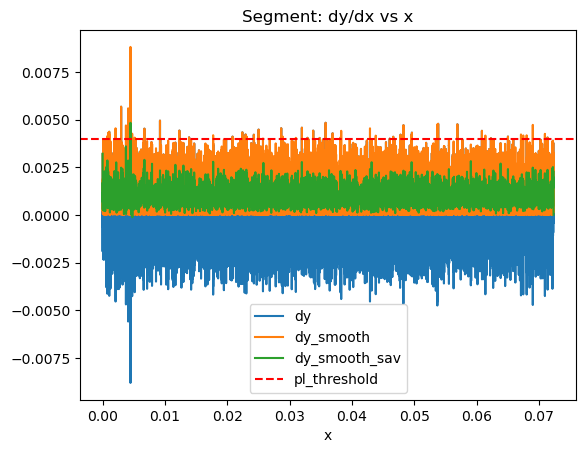

0.004
pl_min_width_points: 1 points, distance = 0.00e+00 m
Plateau 0: start=0, end=2230, average=2.59e-10, avg_idx=1242
Plateau 1 (last): start=2236, end=36162, average=1.03e-11, avg_idx=34514
Plateau 0: delta from starting 0 = 2.48e-10
Plateau 1: delta from previous Y_avg=2.59e-10
Plateau 0: delta time from 0 to avg plat=2.48e-03 sec, Y_avg=2.59e-10
Plateau 1: delta time from 0 to avg plat=4.47e-03 sec, Y_avg=7.89e-11
Plateau 2: dy/dx avg=1.12e-03
Plateau 2: dy/dx avg=1.03e-03


In [131]:
# Find plateaus after the contact point and do a double savitszky-golay smoothing
defl_savitz = savitz_defl[index_first_positive:]
displacement = ret_corrected_displacement[index_first_positive:]

# Usage with real data
params = {## time
    'sav_window_length': 50,
    'sav_polyorder': 11,

    'pl_threshold_old': 0.3e-6,
    'pl_threshold': 0.4e-2 ,
    'pl_min_width_um': 0.002,
    'last_num_plateaus': 7,  # Number of plateaus to ignore at the end
}



rel_time = np.arange(len(displacement)) * relative_dt_ret  # Assuming a constant time step

# For relative time, you modified find plateaus to get the relative SR of Retract, which is the 2nd index
plateaus, df_plat = find_plateaus(displacement, defl_savitz, params, dt= relative_dt_ret)



Plateau finder works by:
1. Define the smoothing parameter for `uniform_filter1d`, which will smooth the derivative of y (controlled by `dy_smooth`).
2. Apply Savitzky-Golay smoothing to dy/dx : `sav_window_length` defines the length of the window, and `sav_polyorder` sets the polynomial order. These are set in the `params` dictionary (e.g., `sav_window_length = 10`, `sav_polyorder = 1`).
3. Set the `pl_threshold` to define which peaks (in green), will be taken into the selection of "rupture/unfolding/untethering" events.
Set the plateau minimum width with `pl_min_width`, in terms of the x input's units

In [132]:
import plotly.graph_objects as go

# Prepare the figure
fig = go.Figure()

showDisplacementonX = True # False, will show time on x axis, else meters

if showDisplacementonX:
    rel_time = displacement


# 1. Add main signal trace (Savitzky-Golay smoothed)
fig.add_trace(go.Scatter(
    x=rel_time, y=defl_savitz,
    mode='lines',
    name='Savitzky-Golay Smoothed Deflection'
))

# 2. Add plateau markers with detailed hover info
for i, idx in enumerate(df_plat['plateau_avg_idx']):
    fig.add_trace(go.Scatter(
        x=[rel_time[idx]],
        y=[defl_savitz[idx]],
        mode='markers',
        marker=dict(size=10),
        name=f'Plateau {i}',
        hovertemplate=(
            f'Plat {i}<br>'
            f'Yavg = {df_plat["plateau_avg"].iloc[i]:.2e}<br>'
            f'ΔYavg = {df_plat["delta_avg"].iloc[i]:.2e}<br>'
            f'Δt = {df_plat["delta_time"].iloc[i]:.2e} s<br>'
            f'x̄(dy/dx) = {df_plat["mean dy/dx"].iloc[i]:.2e}<br>'
            f'MSE = {df_plat["plateau_MSE"].iloc[i]:.2e}<br>'
            '<extra></extra>'
        )
    ))

# 3. Overlay plateau rectangles + average and delta lines
colors = ['rgba(31,119,180,0.3)', 'rgba(255,127,14,0.3)', 'rgba(44,160,44,0.3)', 
          'rgba(214,39,40,0.3)', 'rgba(148,103,189,0.3)', 'rgba(140,86,75,0.3)', 
          'rgba(227,119,194,0.3)', 'rgba(127,127,127,0.3)', 'rgba(188,189,34,0.3)', 
          'rgba(23,190,207,0.3)']

shapes = []
for i, (start, end) in enumerate(plateaus):
    # Shaded rectangle
    shapes.append(
        dict(
            type="rect",
            xref="x", yref="paper",
            x0=rel_time[start], x1=rel_time[end-1],
            y0=0, y1=1,
            fillcolor=colors[i % len(colors)],
            line=dict(width=0),
            layer="below"
        )
    )

    # Horizontal average line
    plateau_avg = np.mean(defl_savitz[start:end])
    fig.add_trace(go.Scatter(
        x=[rel_time[start], rel_time[end-1]],
        y=[plateau_avg, plateau_avg],
        mode='lines',
        line=dict(color=colors[i % len(colors)].replace('0.3', '1.0'), width=2, dash='dash'),
        name=f'Avg Pl {i}: {plateau_avg:.2g}'
    ))

    # Vertical delta line from previous plateau
    if i > 0:
        prev_start, prev_end = plateaus[i-1]
        prev_avg = np.mean(defl_savitz[prev_start:prev_end])
        delta_x = rel_time[start]
        fig.add_trace(go.Scatter(
            x=[delta_x, delta_x],
            y=[prev_avg, plateau_avg],
            mode='lines',
            line=dict(color='black', width=1, dash='dot'),
            name=f'Δ {i-1}-{i}: {plateau_avg - prev_avg:.2g}'
        ))

if showDisplacementonX:
    xaxis_title = 'Displacement (m)'
else:
    xaxis_title = 'Time (s)'

# 4. Final layout
fig.update_layout(
    title='Detected Plateaus with Averages and Δ',
    xaxis_title=xaxis_title,
    yaxis_title='Deflection (N)',
    legend_title='Legend',
    shapes=shapes,
    showlegend=True
)

fig.show()

In [133]:
# Save as interactive HTML
saveFile = False
if saveFile:
    # Define the path and name for saving the figure
    path= '/Users/evillz/Data/article/tether_figs/'
    name = 'plateau_analysis_vs_timev2_devam'
    fig.write_html(path+name+'.html', full_html=True, include_plotlyjs="include")